In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/output/clustering_results.csv")

df.head()

,timestamp,cluster,CO_GT,NO2_GT,NOx_GT,PT08_S1_CO,PT08_S2_NMHC,PT08_S3_NOx,T,RH,AH
0,2004-03-10 18:00:00,1,0.307758,-0.037558,-0.414742,1.140560,0.372175,0.892583,-0.470560,-0.009173,-0.579294
1,2004-03-10 19:00:00,1,-0.105109,-0.472844,-0.707292,0.829606,0.029389,1.352356,-0.504410,-0.077934,-0.660066
2,2004-03-10 20:00:00,1,0.032514,-0.016830,-0.577270,1.332621,-0.030881,1.219879,-0.662375,0.283065,-0.598299
3,2004-03-10 21:00:00,1,0.032514,0.148994,-0.386880,1.213726,0.003021,1.032852,-0.763925,0.626874,-0.507024
4,2004-03-10 22:00:00,1,-0.380354,0.024626,-0.577270,0.738148,-0.418870,1.473143,-0.741358,0.603953,-0.501772


In [3]:
print("Shape:", df.shape)

df["cluster"].value_counts()

Shape: (6941, 11)


cluster
1    2674
0    2295
2    1972
Name: count, dtype: int64

In [4]:
cluster_counts = df["cluster"].value_counts()

print(cluster_counts)

cluster
1    2674
0    2295
2    1972
Name: count, dtype: int64


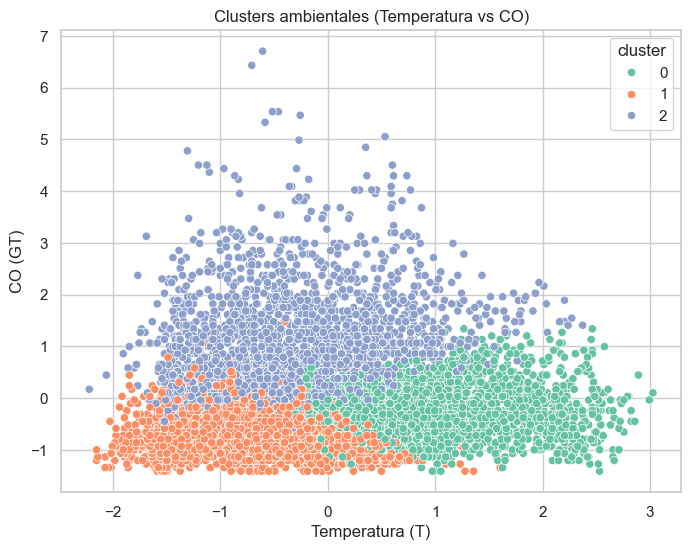

In [5]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="T",
    y="CO_GT",
    hue="cluster",
    palette="Set2"
)

plt.title("Environmental clusters (temperature vs. CO)")
plt.xlabel("Temperature (T)")
plt.ylabel("CO (GT)")

plt.show()

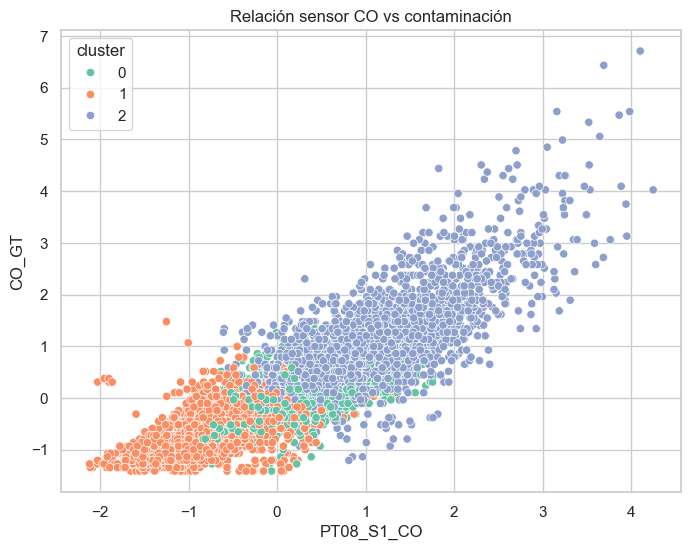

In [6]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PT08_S1_CO",
    y="CO_GT",
    hue="cluster",
    palette="Set2"
)

plt.title("CO sensor reading vs. pollution")

plt.show()

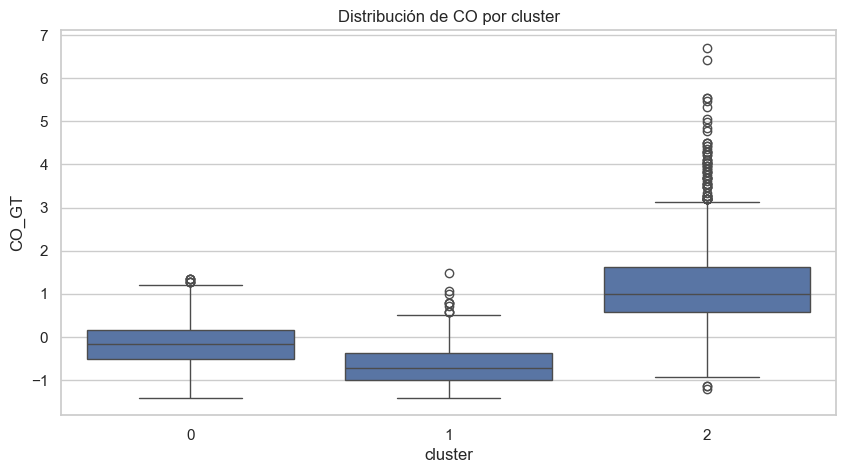

In [7]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="cluster",
    y="CO_GT"
)

plt.title("CO distribution by cluster")

plt.show()

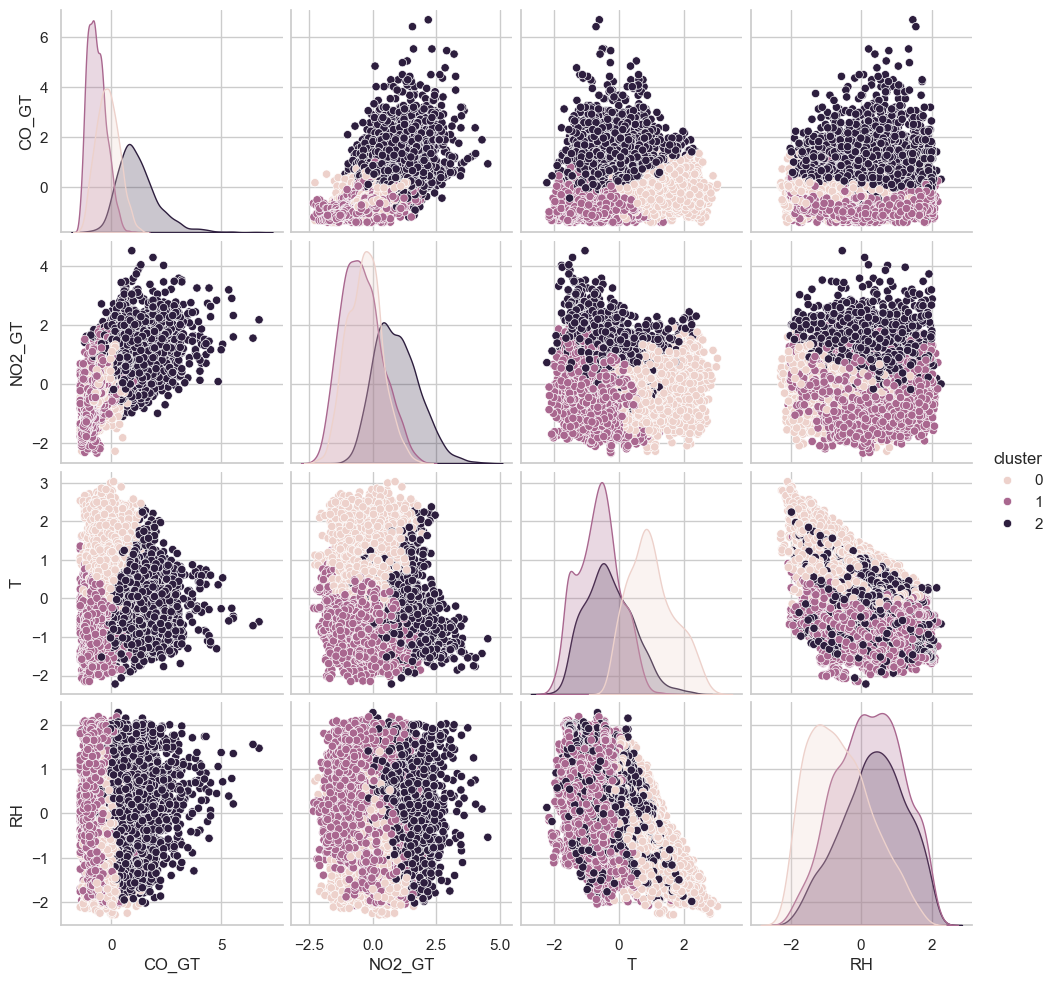

In [8]:
sns.pairplot(
    df[["CO_GT", "NO2_GT", "T", "RH", "cluster"]],
    hue="cluster"
)

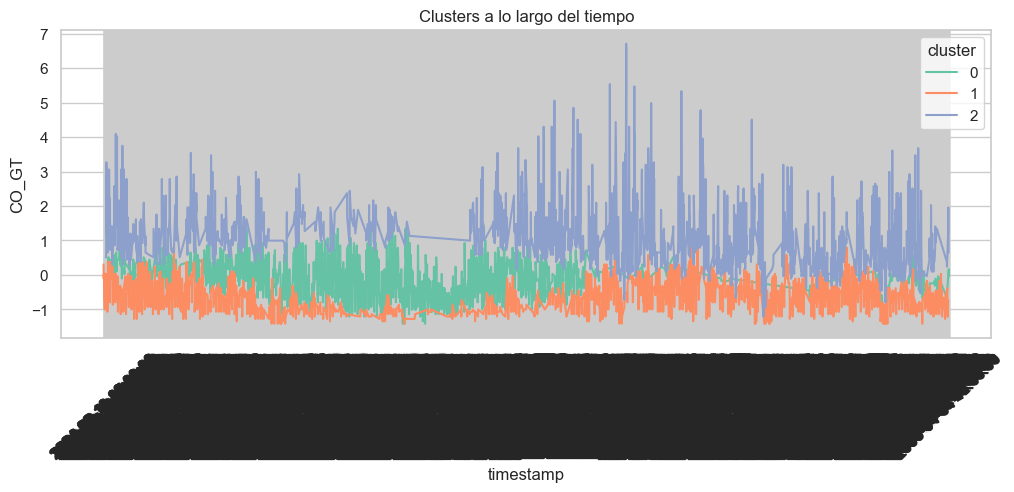

In [9]:
df_sorted = df.sort_values("timestamp")

plt.figure(figsize=(12,4))

sns.lineplot(
    x=df_sorted["timestamp"],
    y=df_sorted["CO_GT"],
    hue=df_sorted["cluster"],
    palette="Set2"
)

plt.xticks(rotation=45)
plt.title("Clusters over time")

plt.show()

In [10]:
cluster_means = df.groupby("cluster").mean(numeric_only=True)

cluster_means[["CO_GT", "NO2_GT", "T", "RH"]]

,CO_GT,NO2_GT,T,RH
cluster,,,,
0,-0.178477,-0.336085,0.999759,-0.599570
1,-0.669674,-0.454674,-0.639442,0.235492
2,1.187753,0.939241,-0.302438,0.342517


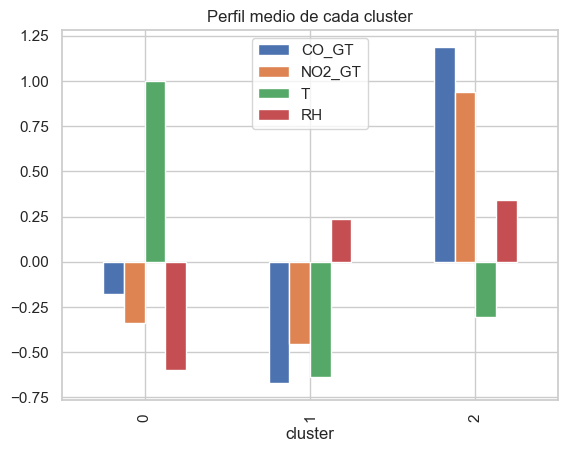

In [11]:
cluster_means[["CO_GT", "NO2_GT", "T", "RH"]].plot(kind="bar")

plt.title("Mean profile of each cluster")

plt.show()

In [12]:
print("Cluster interpretation:\n")

for cluster_id in cluster_means.index:
    avg_co = cluster_means.loc[cluster_id, "CO_GT"]

    print(f"Cluster {cluster_id}:")
    
    if avg_co < df["CO_GT"].mean():
        print(" → Low pollution")
    else:
        print(" → High pollution")

    print()

Cluster interpretation:

Cluster 0:
 → Low pollution

Cluster 1:
 → Low pollution

Cluster 2:
 → High pollution

